In [2]:
using Pkg
Pkg.activate("../")
Pkg.instantiate()

  Activating project at `~/Documents/PauliPropagation/mean_field/PauliOperators.jl`


In [3]:
using PauliOperators
using Plots
using LinearAlgebra
using Plots.PlotMeasures
using KrylovKit


In [4]:
function heisenberg_1d(N::Int; J::Real=1.0)
    H = PauliSum(N, ComplexF64)
    for i in 1:(N-1)
        H[PauliBasis(Pauli(N; X=[i, i+1]))] = .1J + 0im
        H[PauliBasis(Pauli(N; Y=[i, i+1]))] = .1J + 0im
        H[PauliBasis(Pauli(N; Z=[i, i+1]))] = 2J + 0im
    end
    return H
end
  

function fast_exact_ev_curve(H::PauliSum{N}, O::PauliSum{N}, ψ::Ket{N},
                             times::AbstractVector) where {N}
    # Note: If your library supports sparse(H), USE IT here instead of Matrix(H)!
    Hm  = Hermitian(Matrix(H)) 
    Om  = Matrix(O)
    Om2 = Om * Om
    
    ψv = zeros(ComplexF64, Int(2^N))
    ψv[Int(ψ.v) + 1] = 1.0

    ev  = zeros(Float64, length(times))
    var = zeros(Float64, length(times))
    
    # Calculate dt assuming uniform spacing
    dt = times[2] - times[1] 
    
    # Initial state
    ψt = copy(ψv)
    ev[1]  = real(ψt' * Om  * ψt)
    var[1] = real(ψt' * Om2 * ψt) - ev[1]^2

    for k in 2:length(times)
        # Step the state forward by dt using Krylov methods
        # ishermitian=true allows KrylovKit to use the highly efficient Lanczos algorithm
        ψt, info = exponentiate(Hm, -1im * dt, ψt; ishermitian=true, tol=1e-10)
        
        ev[k]  = real(ψt' * Om  * ψt)
        
        var[k] = real(ψt' * Om2 * ψt) - ev[k]^2
    end
    
    return ev, var
end

"""
Exact dynamics via eigendecomposition of H: ⟨ψ(t)| O |ψ(t)⟩ and Var_ψ(t)(O).
"""
function exact_ev_curve(H::PauliSum{N}, O::PauliSum{N}, ψ::Ket{N},
                        times::AbstractVector) where {N}
    Hm  = Hermitian(Matrix(H))
    Om  = Matrix(O)
    Om2 = Om * Om
    ψv = zeros(ComplexF64, Int(2^N))
    ψv[Int(ψ.v) + 1] = 1.0

    F = eigen(Hm)
    λ, V = F.values, F.vectors
    c0 = V' * ψv

    ev  = zeros(Float64, length(times))
    var = zeros(Float64, length(times))
    for (k, t) in enumerate(times)
        ψt = V * (cis.(-t .* λ) .* c0)
        ev[k]  = real(ψt' * Om  * ψt)
        var[k] = real(ψt' * Om2 * ψt) - ev[k]^2
    end
    return ev, var
end

function get_weight_distribution(ps::PauliSum, N::Int)
    # Array to hold weights from 0 up to N (size N+1 to account for weight 0)
    dist = zeros(Float64, N + 1) 
    
    for (p, c) in ps
        w = weight(p)
        # We use squared coefficients (probability mass)
        dist[w + 1] += abs2(c) 
    end
    
    return dist
end


"""
Heisenberg-picture Trotter evolution of `O`. One second-order Trotter step
per recorded time (i.e. `times` must be uniformly spaced by `dt`).
Returns (ev_curve, var_curve, n_terms_curve).
"""
function trotter_ev_curve(H::PauliSum{N,T}, O::PauliSum{N,T}, ψ::Ket{N},
                          times::AbstractVector, dt::Real,
                          truncation::TruncationStrategy, correction::CorrectionAccumulator=NoCorrection()) where {N,T}
    generators, angles = trotterize(H, dt; n_trotter=1, order=2)
    Ot = deepcopy(O)
    W_mat   = zeros(Float64, length(times), N + 1)
    ev      = zeros(Float64, length(times))
    var     = zeros(Float64, length(times))
    n_terms = zeros(Int,     length(times))
    ev[1]      = real(expectation_value(Ot, ψ))
    var[1]     = variance(Ot, ψ)
    n_terms[1] = length(Ot)
    W_mat[1, :] = get_weight_distribution(Ot, N)
    l2 = norm(H)
    for step in 2:length(times)
        Ot = evolve(Ot, generators, angles; truncation=truncation, correction=correction)
        # mul!(Ot, l2 / norm(Ot))
        # @show norm(Ot)
        if correction isa EnergyCorrection
            ev[step] = real(expectation_value(Ot, ψ) - correction.accumulated_energy)
        else
            ev[step]  = real(expectation_value(Ot, ψ))
        end
        var[step]     = variance(Ot, ψ)
        n_terms[step] = length(Ot)
        W_mat[step, :] = get_weight_distribution(Ot, N)
    end
    return ev, var, n_terms, W_mat
end


trotter_ev_curve

### Time Evolution of the XXZ Model

In this experiment, we simulate the time evolution of the observable $Z_{12}$ under a 10-site  Heisenberg (XXZ) Hamiltonian. 

The Hamiltonian is defined as:

$$H = \sum_{i} \left( 0.1J X_i X_{i+1} + 0.1J Y_i Y_{i+1} + 2J Z_i Z_{i+1} \right)$$

**Simulation Parameters:**
* **System Size ($N$):** 10 sites 
* **Observable:** $\langle \psi | Z_{1}Z_{2}(t) | \psi \rangle$
* **State:** $|\psi \rangle = |0101010101 \rangle$
* **Coupling ($J$):** Base energy scale J = 1

|0101010101>

  1D Heisenberg | N=10 sites, J=1.0, ψ=|682⟩, observable Z_16
  dt=0.04, T=5.0

  exact (dense)...  1.229687 seconds (3.04 M allocations: 628.659 MiB, 12.94% gc time, 35.07% compilation time)


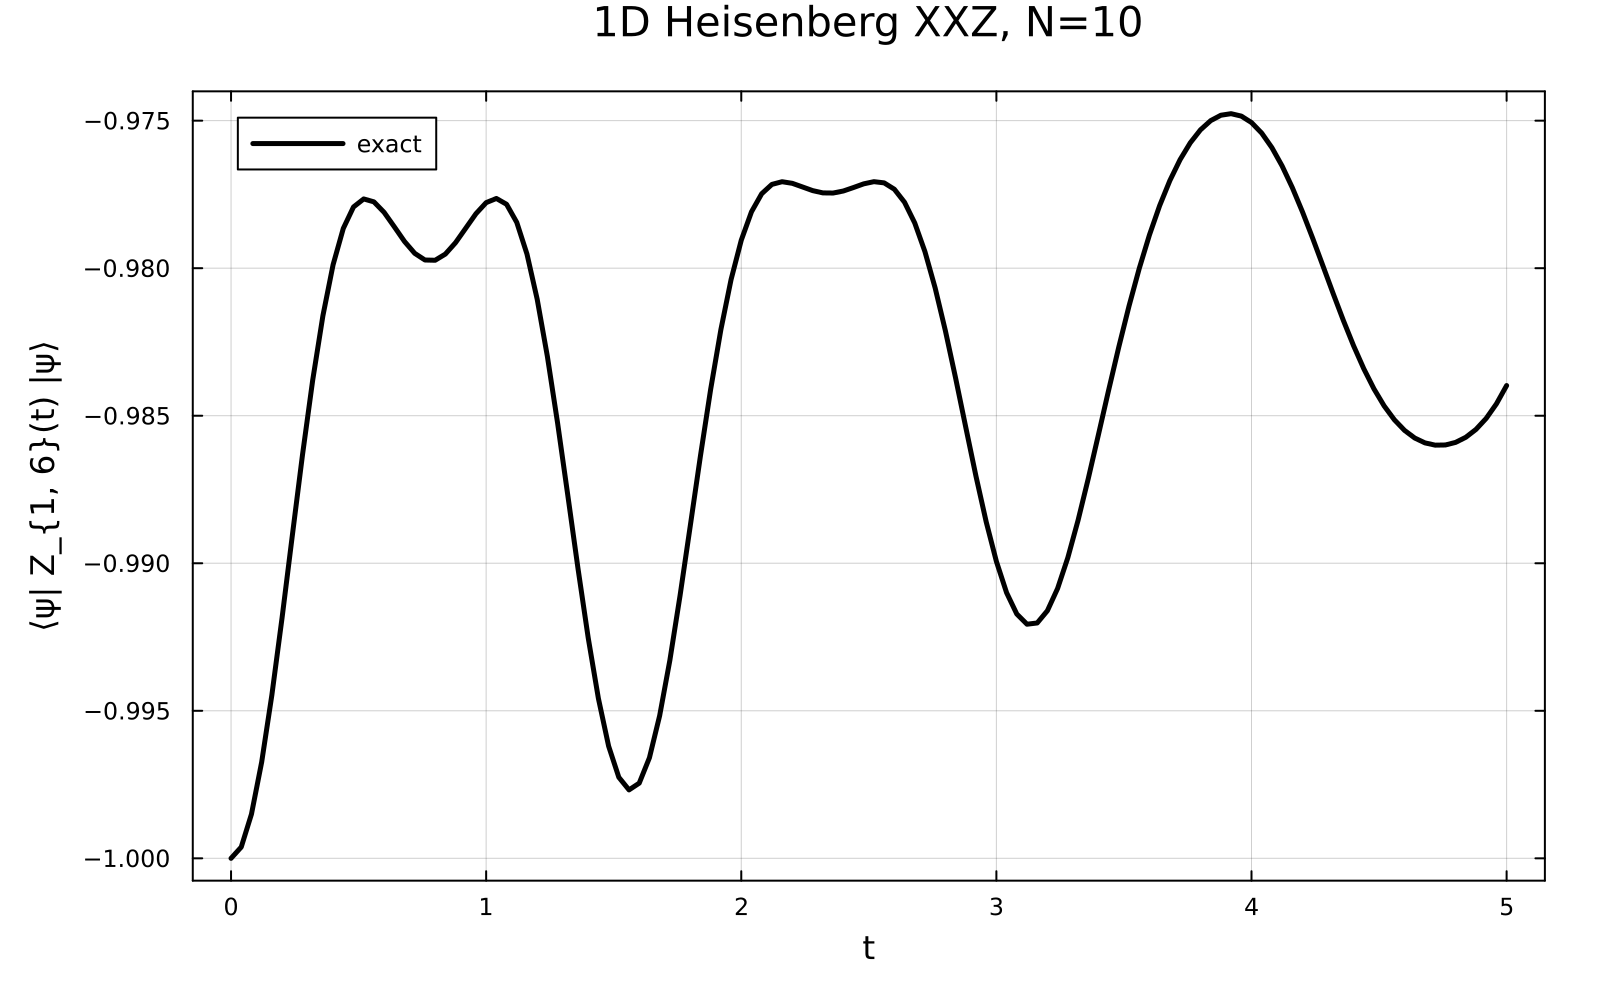

In [ ]:
N      = 10
J      = 1.0
dt     = 0.04
T_max  = 5.0
times  = collect(0.0:dt:T_max)

H = heisenberg_1d(N; J=J)

# ψ = Ket(N, Int128(0b0101010101))
ψ = Ket(repeat([0, 1], 5))
# ψ = Ket{N}(0)

display(ψ)
O = PauliSum(Pauli(N; Z=[1, 6]))

println("=" ^ 82)
println("  1D Heisenberg | N=$N sites, J=$J, ψ=|$(ψ.v)⟩, observable Z_16")
println("  dt=$dt, T=$T_max")
println("=" ^ 82)
println()

print("  exact (dense)...")
@time ev_exact, var_exact = exact_ev_curve(H, O, ψ, times)
# @time ev_exact, var_exact = fast_exact_ev_curve(H, O, ψ, times)
    

p1 = plot(times, ev_exact, label="exact",
            color=:black, lw=2.5, ls=:solid,
            xlabel="t", ylabel="⟨ψ| Z_{1, 6}(t) |ψ⟩",
            title="1D Heisenberg XXZ, N=$(N)",
            legend=:topleft, size=(800, 500),framestyle=:box, margin=5Plots.mm, dpi = 200) 

# p1 = plot(xlabel="t", ylabel="⟨ψ| Z_{1, 2}(t) |ψ⟩",
#             title="1D Heisenberg XXZ, N=$(N)",
#             legend=:topleft, size=(800, 500))

p1

### Pauli Propagation

Now we use **Pauli propagation** with a coefficient threshold of $10^{-4}$ (`1e-4`) to carry out the same dynamics described above.

 24.415949 seconds (1.13 M allocations: 27.136 GiB, 13.23% gc time, 0.98% compilation time)


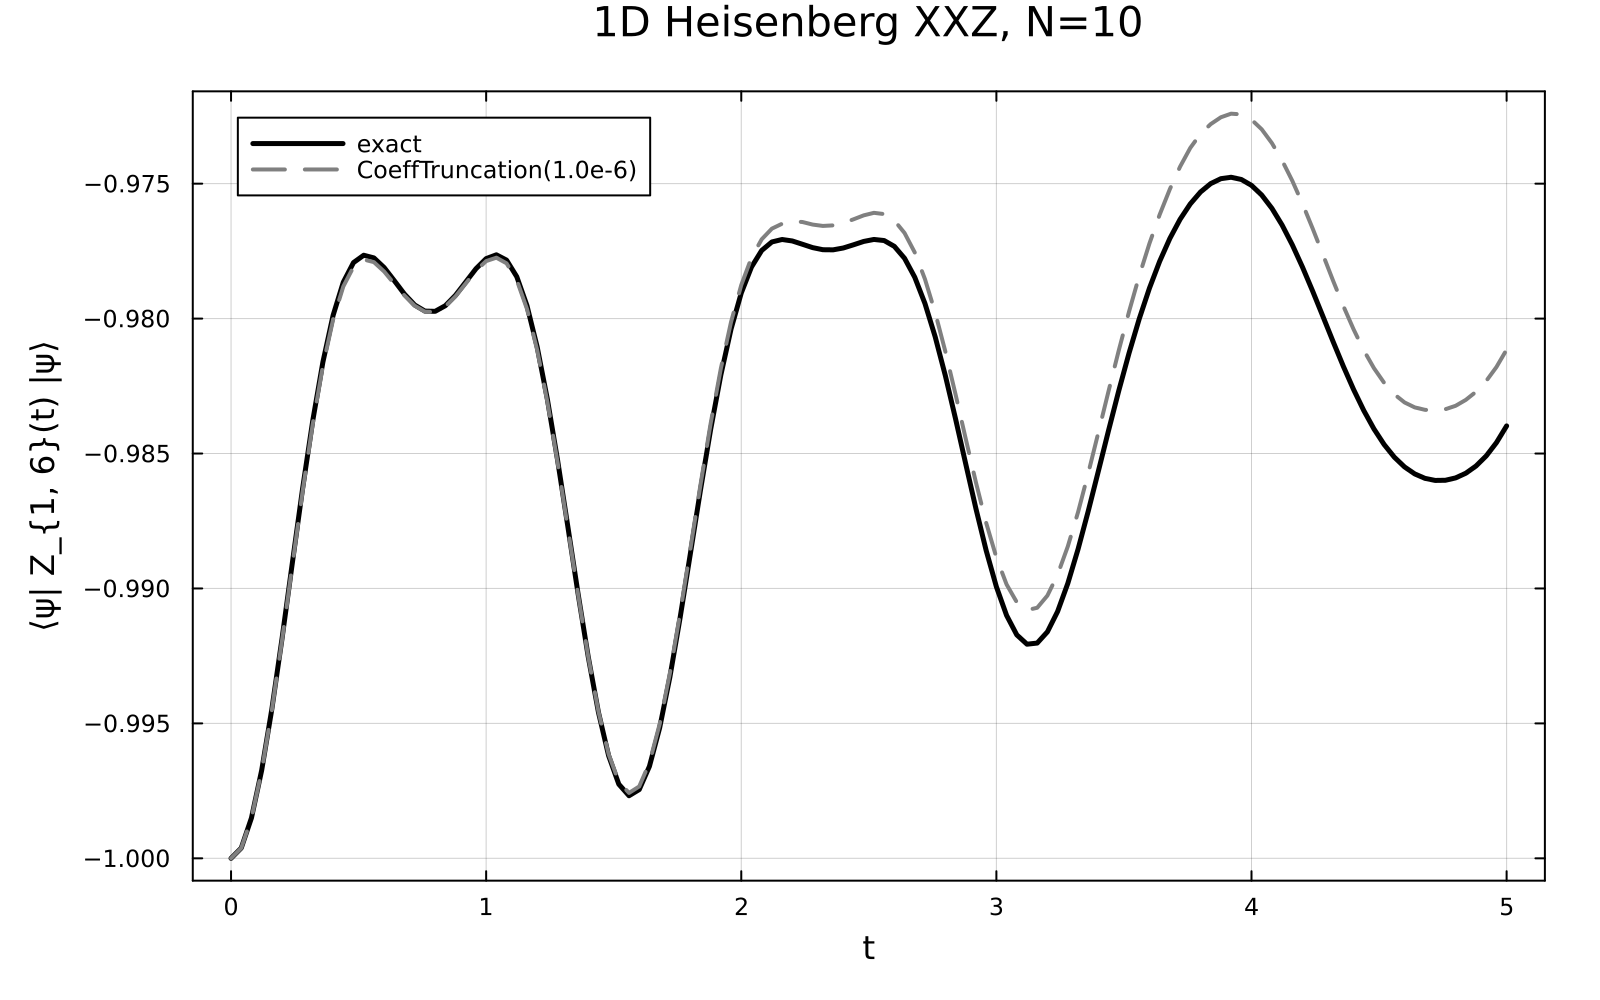

In [8]:
thresh = 1e-6
@time ev_tr, var_tr, nt_tr, W_mat_coeft = trotter_ev_curve(H, O, ψ, times, dt, CoeffTruncation(thresh))


plot!(p1, times, ev_tr,
          label="CoeffTruncation($(thresh))", color=:gray, ls=:dash, lw = 2)
    
p1    

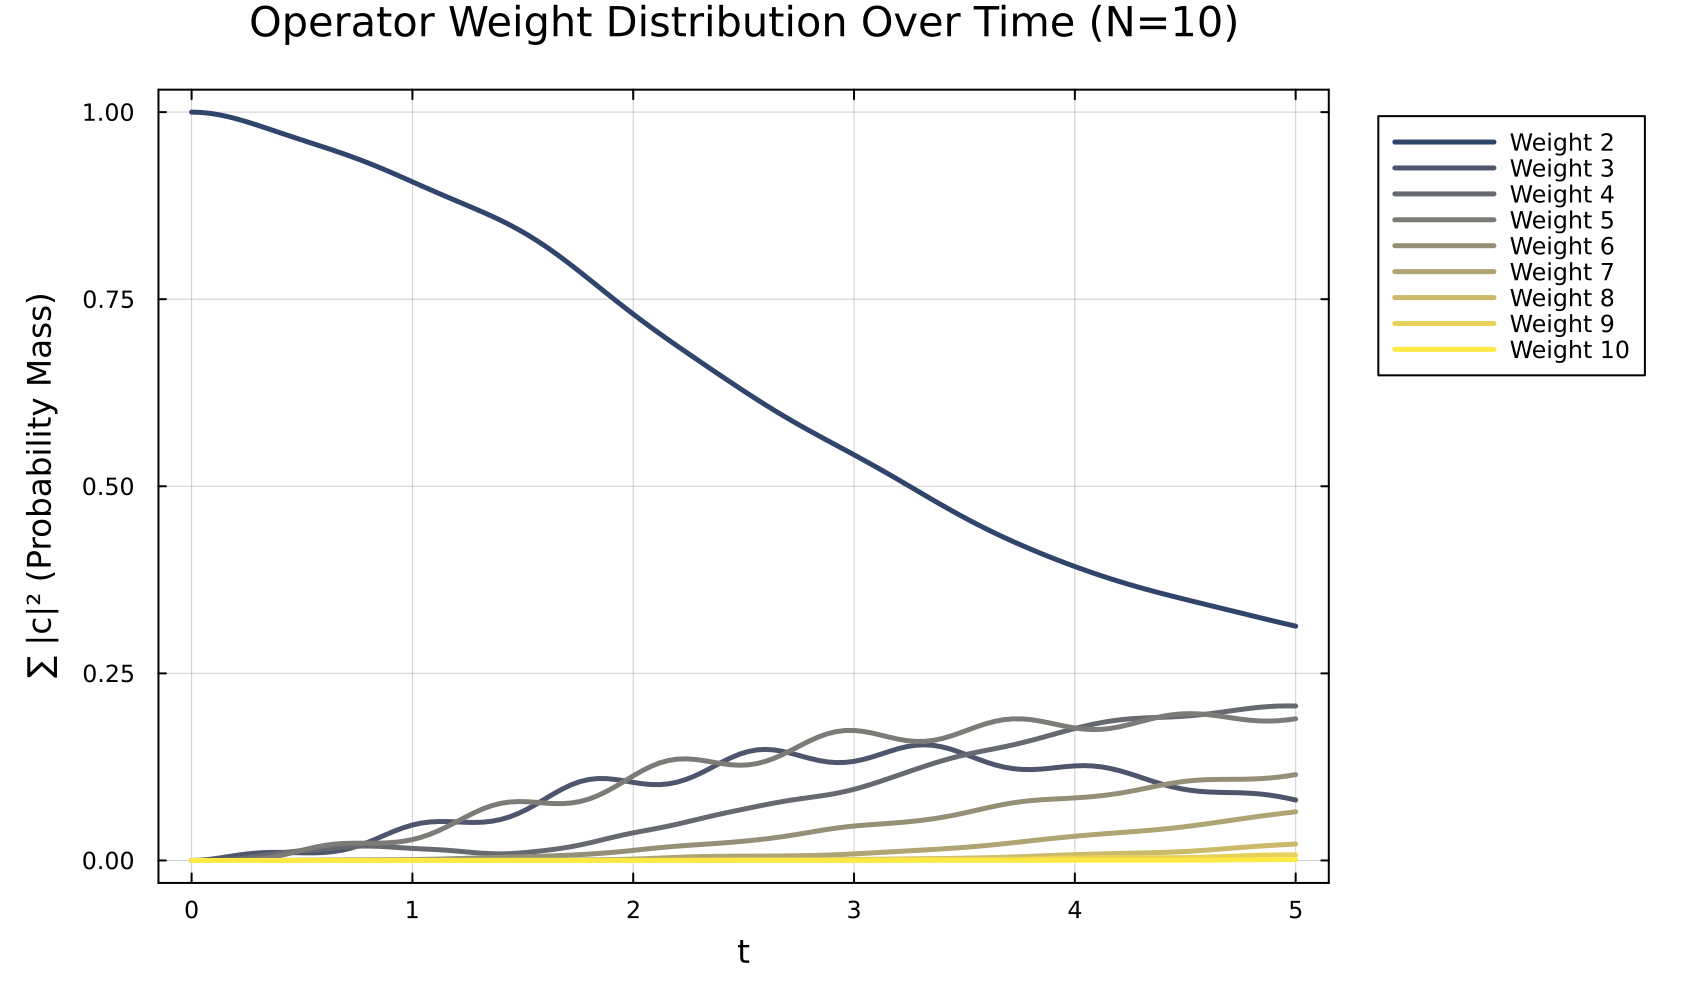

In [9]:
p_dist = plot(xlabel="t", 
              ylabel="∑ |c|² (Probability Mass)",
              title="Operator Weight Distribution Over Time (N=$(N))",
              legend=:outertopright,  # Moves legend outside so it doesn't cover data
              size=(850, 500), 
              framestyle=:box)

# Get a continuous color gradient
my_colors = cgrad(:cividis, N + 1, categorical=true)

for w in 0:N
    # Only plot the line if this weight actually appeared in the simulation
    if maximum(W_mat_coeft[:, w+1]) > 1e-10
        plot!(p_dist, times, W_mat_coeft[:, w+1], 
              label="Weight $w", 
              linewidth=2.5, 
              color=my_colors[w+1],  margin=5Plots.mm, dpi = 200)
    end
end

display(p_dist)

  0.793350 seconds (197.02 k allocations: 827.211 MiB, 1.60% gc time, 2.56% compilation time)


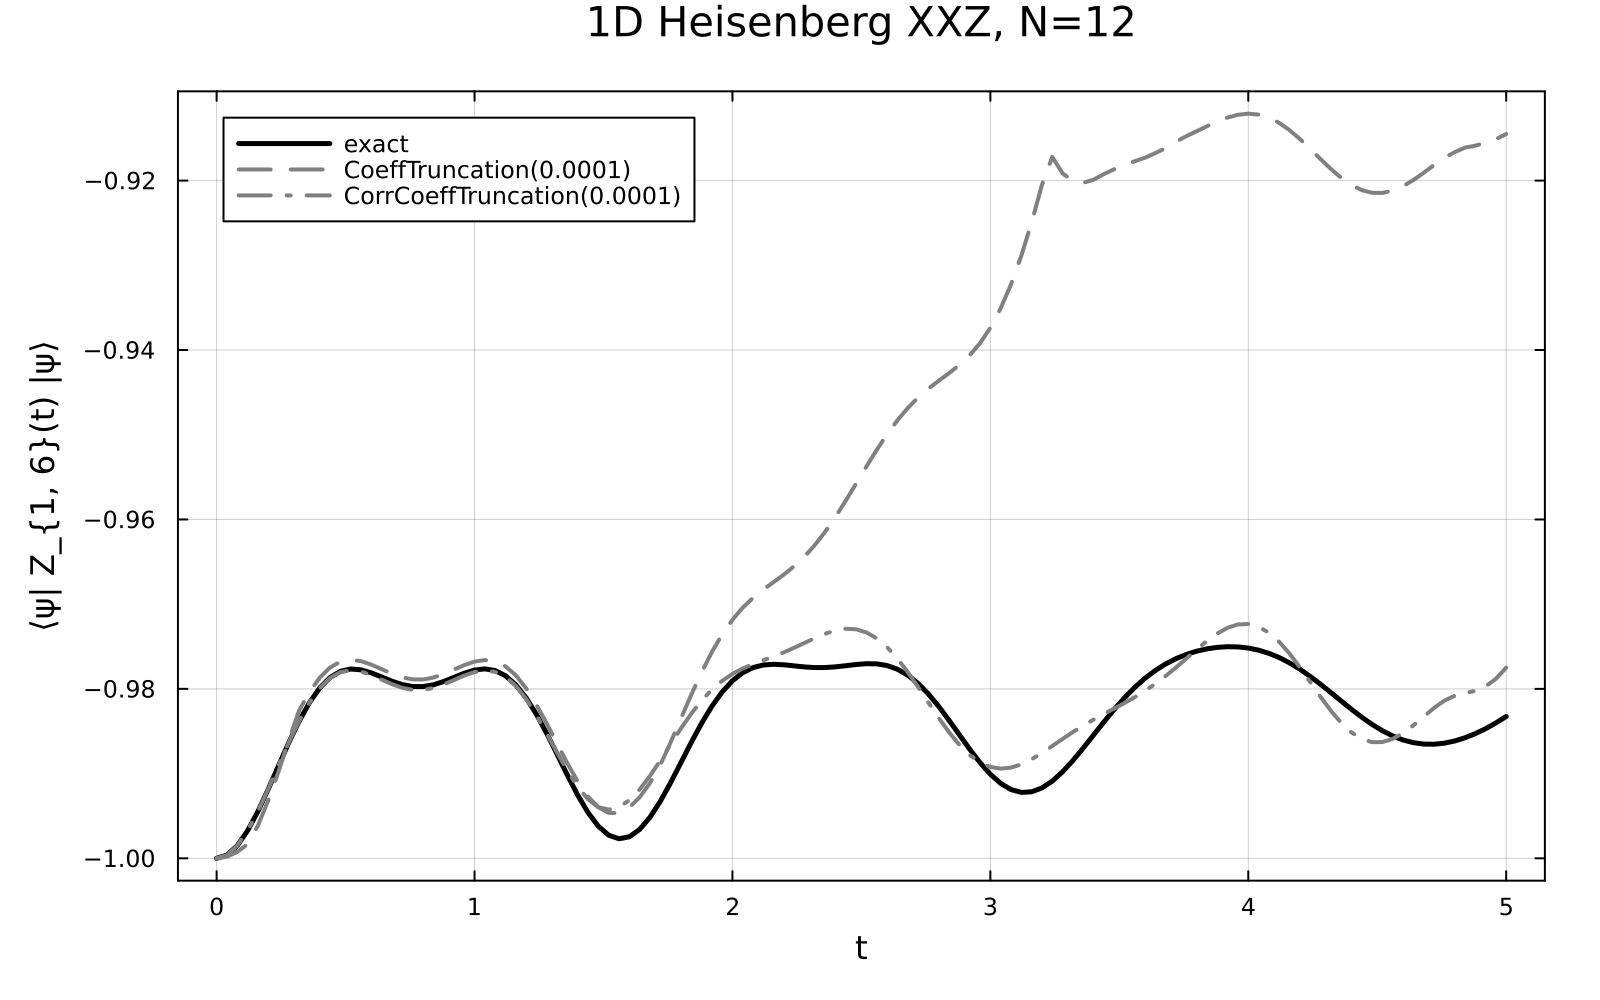

In [61]:
corr = EnergyCorrection(ψ)
@time ev_tr, var_tr, nt_tr, W_mat_corr = trotter_ev_curve(H, O, ψ, times, dt, CoeffTruncation(thresh),  corr)
# display(corr)

plot!(p1, times, ev_tr,
          label="CorrCoeffTruncation($(thresh))", color=:gray, ls=:dashdot, lw = 2)

p1

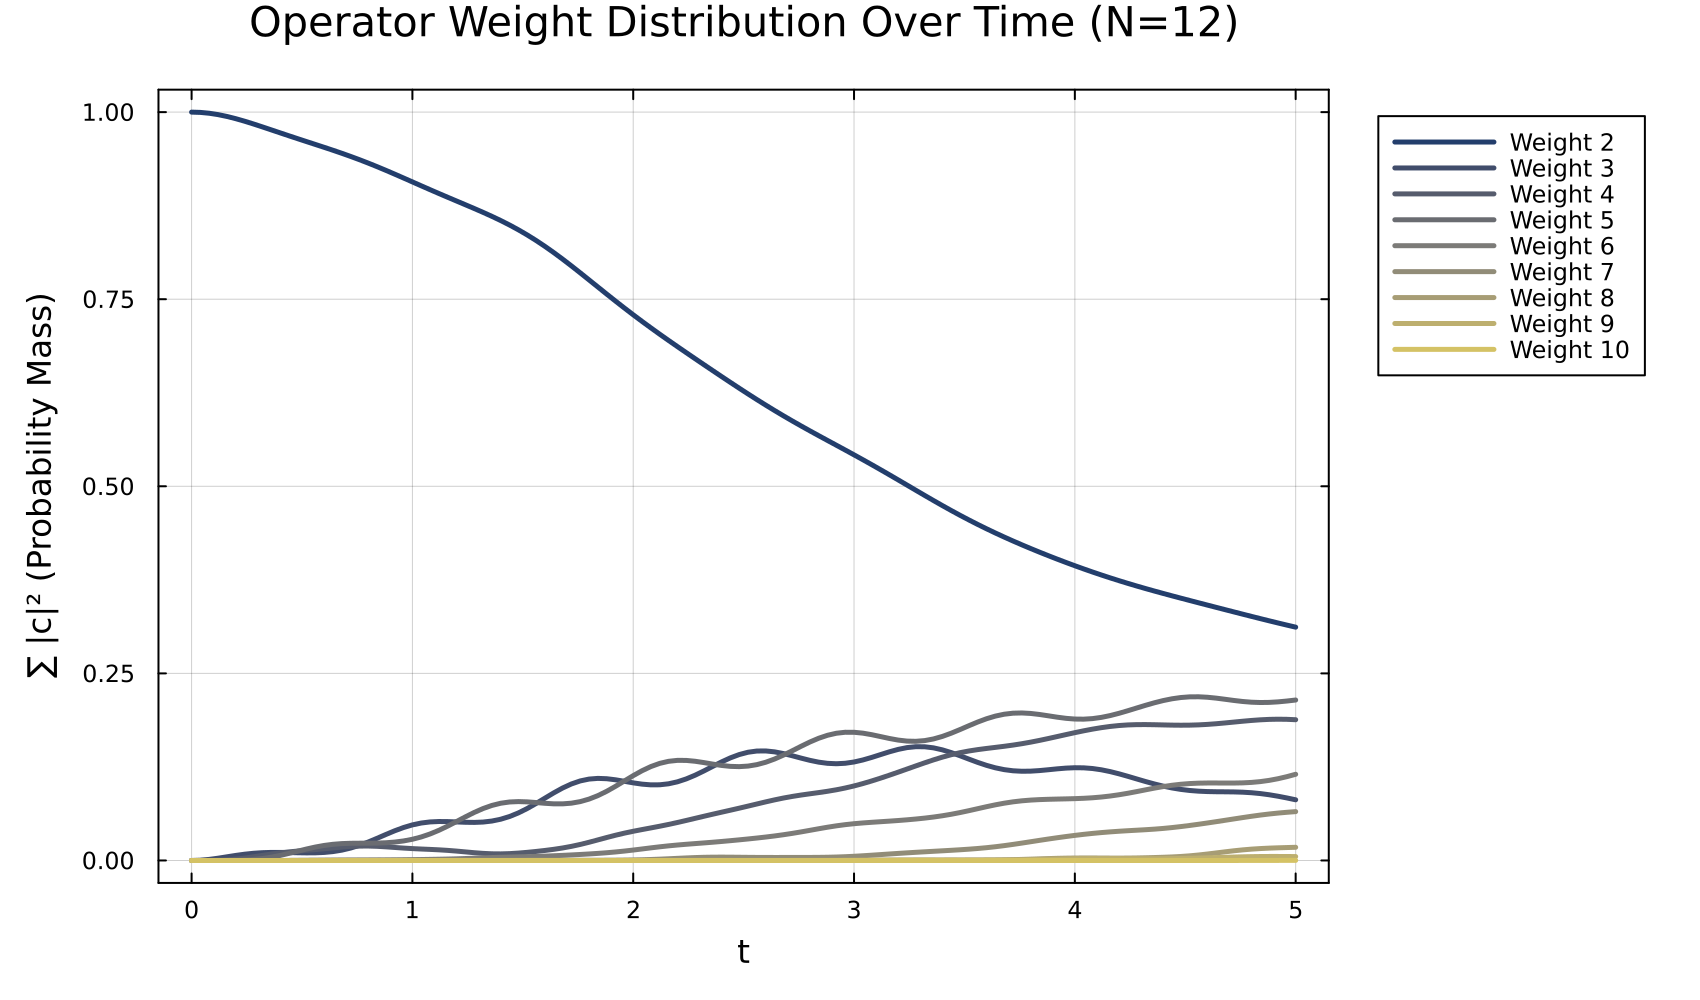

In [62]:
p_dist_corr = plot(xlabel="t", 
              ylabel="∑ |c|² (Probability Mass)",
              title="Operator Weight Distribution Over Time (N=$(N))",
              legend=:outertopright,  # Moves legend outside so it doesn't cover data
              size=(850, 500), 
              framestyle=:box)

# Get a continuous color gradient
my_colors = cgrad(:cividis, N + 1, categorical=true)

for w in 0:N
    # Only plot the line if this weight actually appeared in the simulation
    if maximum(W_mat_corr[:, w+1]) > 1e-10
        plot!(p_dist_corr, times, W_mat_corr[:, w+1], 
              label="Weight $w", 
              linewidth=2.5, 
              color=my_colors[w+1],  margin=5Plots.mm, dpi = 200)
    end
end

display(p_dist_corr)

Now we take a look at the weight truncation, where we set the maximum weight to $k_{max} = 3$

  trotter + weight(k=4)...                   0.084464 seconds (154.74 k allocations: 80.449 MiB, 6.34% gc time, 35.04% compilation time)


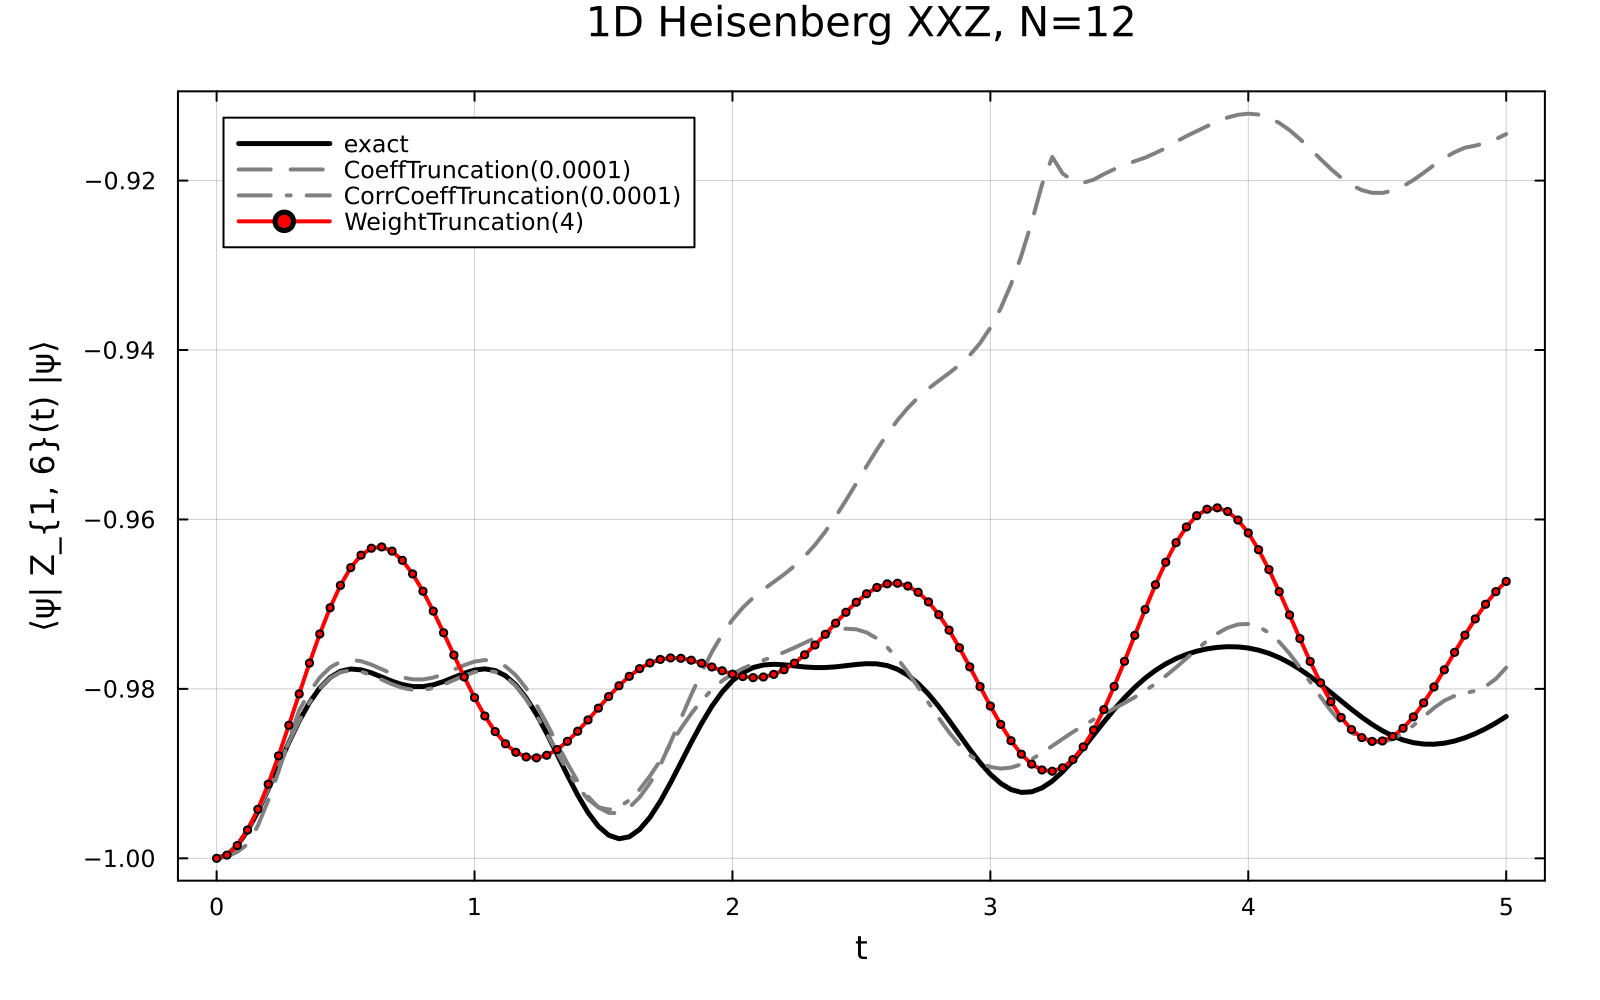

In [63]:
k_max = 4
print("  trotter + weight(k=$k_max)...                 ")
@time ev_wt, var_wt, nt_wt, W_mat_wt = trotter_ev_curve(H, O, ψ, times, dt,
        CompositeTruncation(WeightTruncation(k_max), CoeffTruncation(1e-5)))

plot!(p1, times, ev_wt,
          label="WeightTruncation($(k_max))",
          color=:red,  lw=2, marker=:circle, ms=2)

p1

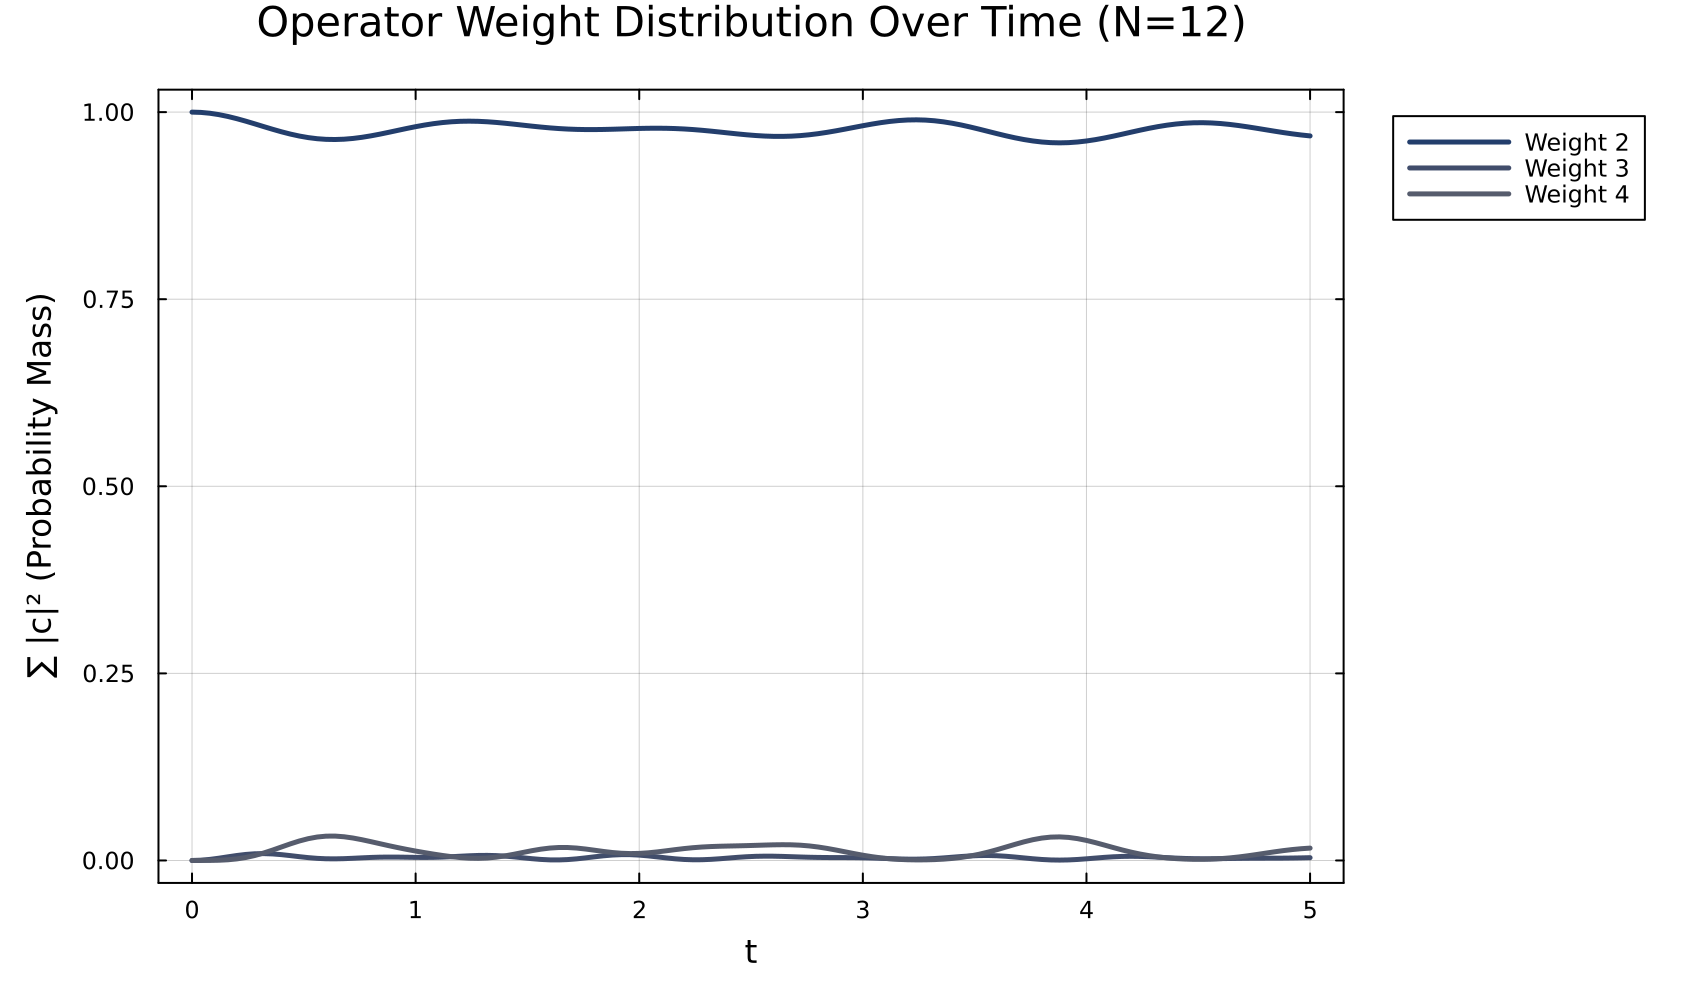

In [64]:
p_dist_wt = plot(xlabel="t", 
              ylabel="∑ |c|² (Probability Mass)",
              title="Operator Weight Distribution Over Time (N=$(N))",
              legend=:outertopright,  # Moves legend outside so it doesn't cover data
              size=(850, 500), 
              framestyle=:box)

# Get a continuous color gradient
my_colors = cgrad(:cividis, N + 1, categorical=true)

for w in 0:N
    # Only plot the line if this weight actually appeared in the simulation
    if maximum(W_mat_wt[:, w+1]) > 1e-10
        plot!(p_dist_wt, times, W_mat_wt[:, w+1], 
              label="Weight $w", 
              linewidth=2.5, 
              color=my_colors[w+1],  margin=5Plots.mm, dpi = 200)
    end
end

display(p_dist_wt)

### Mean-Field Truncation Strategy

Here we look at a menan field correction to the typical truncations. Instead of just clipping off paulistrings, we do a mean field approximation. Consider a Pauli String AB, we can substitute the fluctuation decomposition $A = \delta A + \langle A \rangle I$ and $B = \delta B + \langle B \rangle I$ into the product $AB$. Expanding the terms gives:

$$
\begin{aligned}
AB &= (\delta A + \langle A \rangle I) \otimes (\delta B + \langle B \rangle I) \\
   &= (\delta A \otimes \delta B) + (\delta A \otimes \langle B \rangle I) + (\langle A \rangle I \otimes \delta B) + (\langle A \rangle I \otimes \langle B \rangle I)
\end{aligned}
$$

Since the expectation values $\langle A \rangle$ and $\langle B \rangle$ are scalar quantities, they commute with the operators. Factoring the scalars out, we get:

$$
\begin{aligned}
AB &= \delta A \otimes \delta B + \langle B \rangle (\delta A \otimes I) + \langle A \rangle (I \otimes \delta B) + \langle A \rangle \langle B \rangle (I \otimes I)
\end{aligned}
$$

$$
AB = \delta A \delta B + \langle B \rangle \delta A + \langle A \rangle \delta B + \langle A \rangle \langle B \rangle I
$$

Now, we resubstitute the definitions of the fluctuations, $\delta A = A - \langle A \rangle I$ and $\delta B = B - \langle B \rangle I$, into the linear terms:

$$AB = \delta A \delta B + \langle B \rangle (A - \langle A \rangle I) + \langle A \rangle (B - \langle B \rangle I) + \langle A \rangle \langle B \rangle I$$

Expanding the products gives:

$$AB = \delta A \delta B + \langle B \rangle A - \langle A \rangle \langle B \rangle I + \langle A \rangle B - \langle A \rangle \langle B \rangle I + \langle A \rangle \langle B \rangle I$$

We can combine and cancel the scalar terms ($-\langle A \rangle \langle B \rangle I - \langle A \rangle \langle B \rangle I + \langle A \rangle \langle B \rangle I = -\langle A \rangle \langle B \rangle I$). This simplifies the exact expansion to:

$$AB = \delta A \delta B + \langle B \rangle A + \langle A \rangle B - \langle A \rangle \langle B \rangle I$$

In mean-field theory, we assume that the fluctuations around the mean field are small. Therefore, the product of two fluctuations, $\delta A \delta B$, is considered a higher-order term and becomes negligible:

$$\delta A \delta B \approx 0$$

By dropping this quadratic fluctuation term, we arrive at the standard mean-field approximation for a 2-body operator. The operator $AB$ is factorized down into a sum of 1-body operators:

$$AB \approx \langle B \rangle A + \langle A \rangle B - \langle A \rangle \langle B \rangle I$$

<!-- This is the exact mathematical foundation for why discarding high-weight Pauli strings completely is unphysical, and why replacing them with their localized mean-field values preserves the operator norm. -->

### Walkthrough: Mean-Field Factorization of $X_1 Z_2 Z_3$ ($k=2$)

Let's walk through the exact mathematical factorization of a specific Pauli string, $P = X_1 Z_2 Z_3$, using a target maximum weight of $k=2$. 

Assume our reference computational basis state is $|\psi\rangle = |000\rangle$. In this state, the expectation values of our single-qubit operators are:
* $\langle X_1 \rangle = 0$
* $\langle Z_2 \rangle = 1$
* $\langle Z_3 \rangle = 1$

#### 1. The Algebraic Fluctuation Expansion
The core of the mean-field approximation is rewriting each Pauli operator as its expectation value plus a fluctuation operator, $\delta P = P - \langle P \rangle I$. Therefore:
* $X_1 = 0 + \delta X_1 \implies \delta X_1 = X_1$
* $Z_2 = I + \delta Z_2 \implies \delta Z_2 = Z_2 - I$
* $Z_3 = I + \delta Z_3 \implies \delta Z_3 = Z_3 - I$

Substitute these back into the original operator:
$$P = X_1 (I + \delta Z_2) (I + \delta Z_3)$$

Expanding this polynomial product yields four terms:
$$P = (X_1 \otimes I \otimes I) + (X_1 \otimes \delta Z_2 \otimes I) + (X_1 \otimes I \otimes \delta Z_3) + (X_1 \otimes \delta Z_2 \otimes \delta Z_3)$$

#### 2. Truncating to Order $k=2$
The "weight" of a term in this expansion is determined by how many $\delta$ operators it contains. Because $\langle X_1 \rangle = 0$, the $X_1$ operator is entirely a fluctuation, meaning every term in our expansion already has at least one $\delta$ operator.

To constrain the total operator to a maximum weight of $k=2$, we must drop any term containing more than two $\delta$ operators:
* $X_1$: 1 fluctuation **(Keep)**
* $X_1 \delta Z_2$: 2 fluctuations **(Keep)**
* $X_1 \delta Z_3$: 2 fluctuations **(Keep)**
* $X_1 \delta Z_2 \delta Z_3$: 3 fluctuations **(Drop)**

Our truncated operator becomes:
$$P^{(k=2)} \approx X_1 + X_1 \delta Z_2 + X_1 \delta Z_3$$

#### 3. Converting Back to Standard Paulis
Now we substitute $\delta Z_i = Z_i - I$ back into the truncated expression to return to standard Pauli strings:
$$P^{(k=2)} = X_1 + X_1(Z_2 - I) + X_1(Z_3 - I)$$
$$P^{(k=2)} = X_1 + X_1 Z_2 - X_1 + X_1 Z_3 - X_1$$
$$P^{(k=2)} = X_1 Z_2 + X_1 Z_3 - X_1$$

A weight-3 operator has been successfully approximated by a sum of weight-2 and weight-1 operators.


  trotter + mean-field(k=4, ψ)...            5.035501 seconds (127.93 M allocations: 10.616 GiB, 6.98% gc time, 1.36% compilation time)


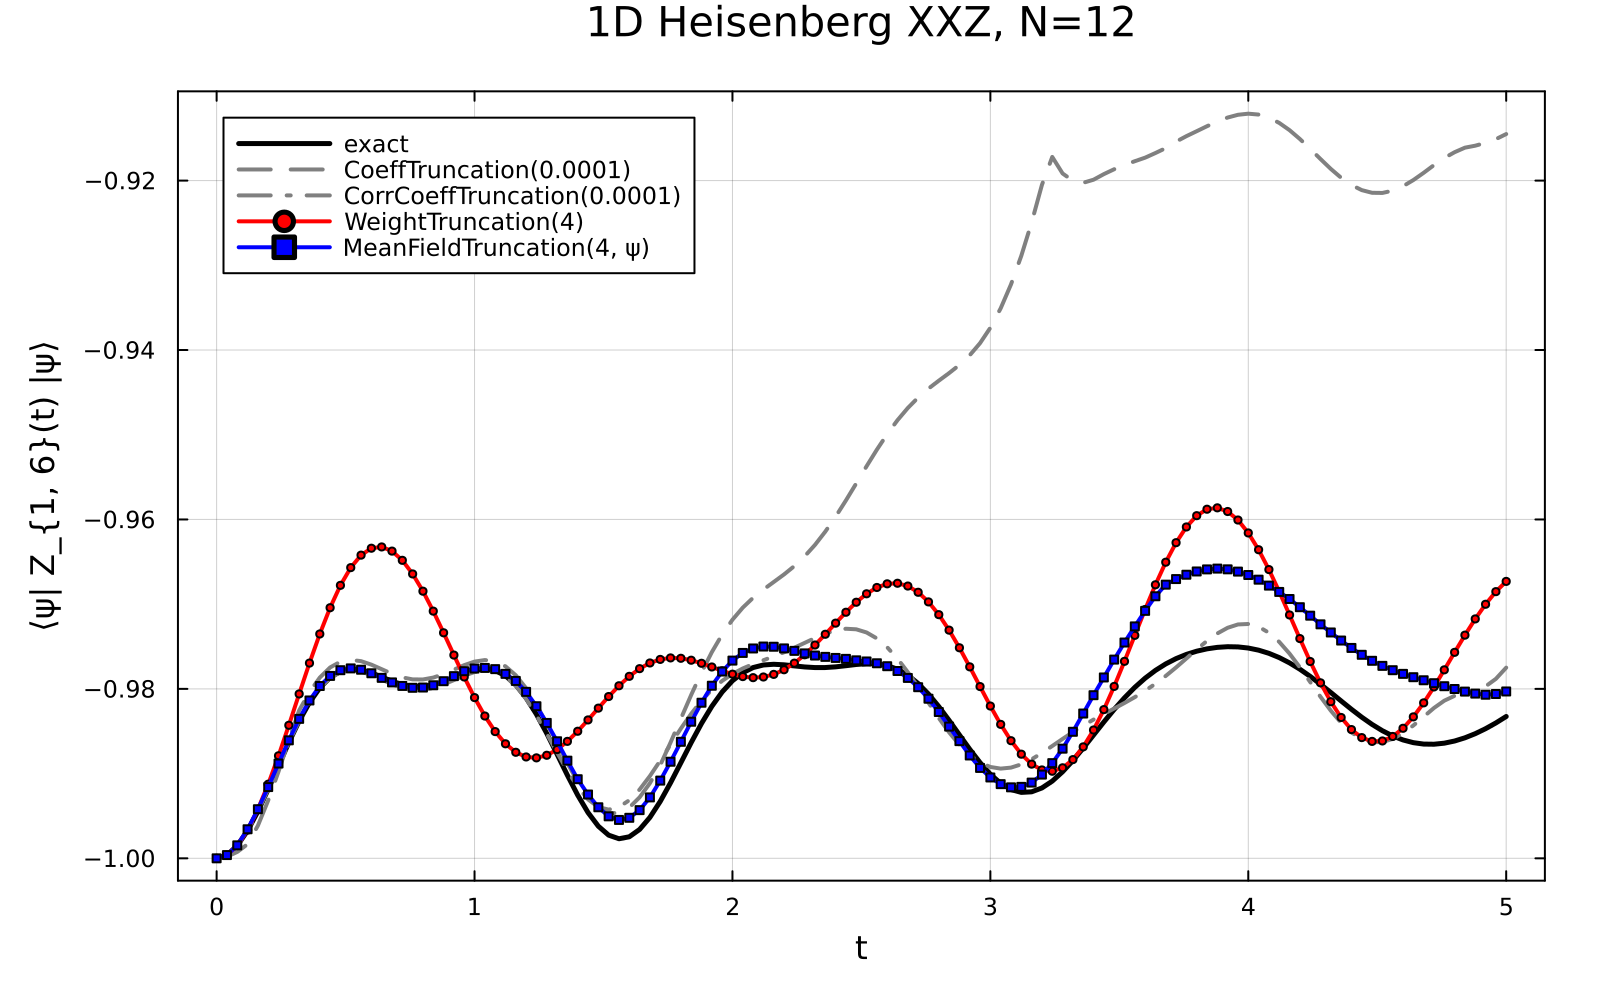

In [ ]:

print("  trotter + mean-field(k=$k_max, ψ)...          ")
    @time ev_mf, var_mf, nt_mf, W_mat_mf = trotter_ev_curve(H, O, ψ, times, dt,
        CompositeTruncation(MeanFieldTruncation(k_max, ψ), CoeffTruncation(1e-5)))

plot!(p1, times, ev_mf,
          label="MeanFieldTruncation($(k_max), ψ)",
          color=:blue, lw=2, marker=:square, ms=2, markevery=5)

p1

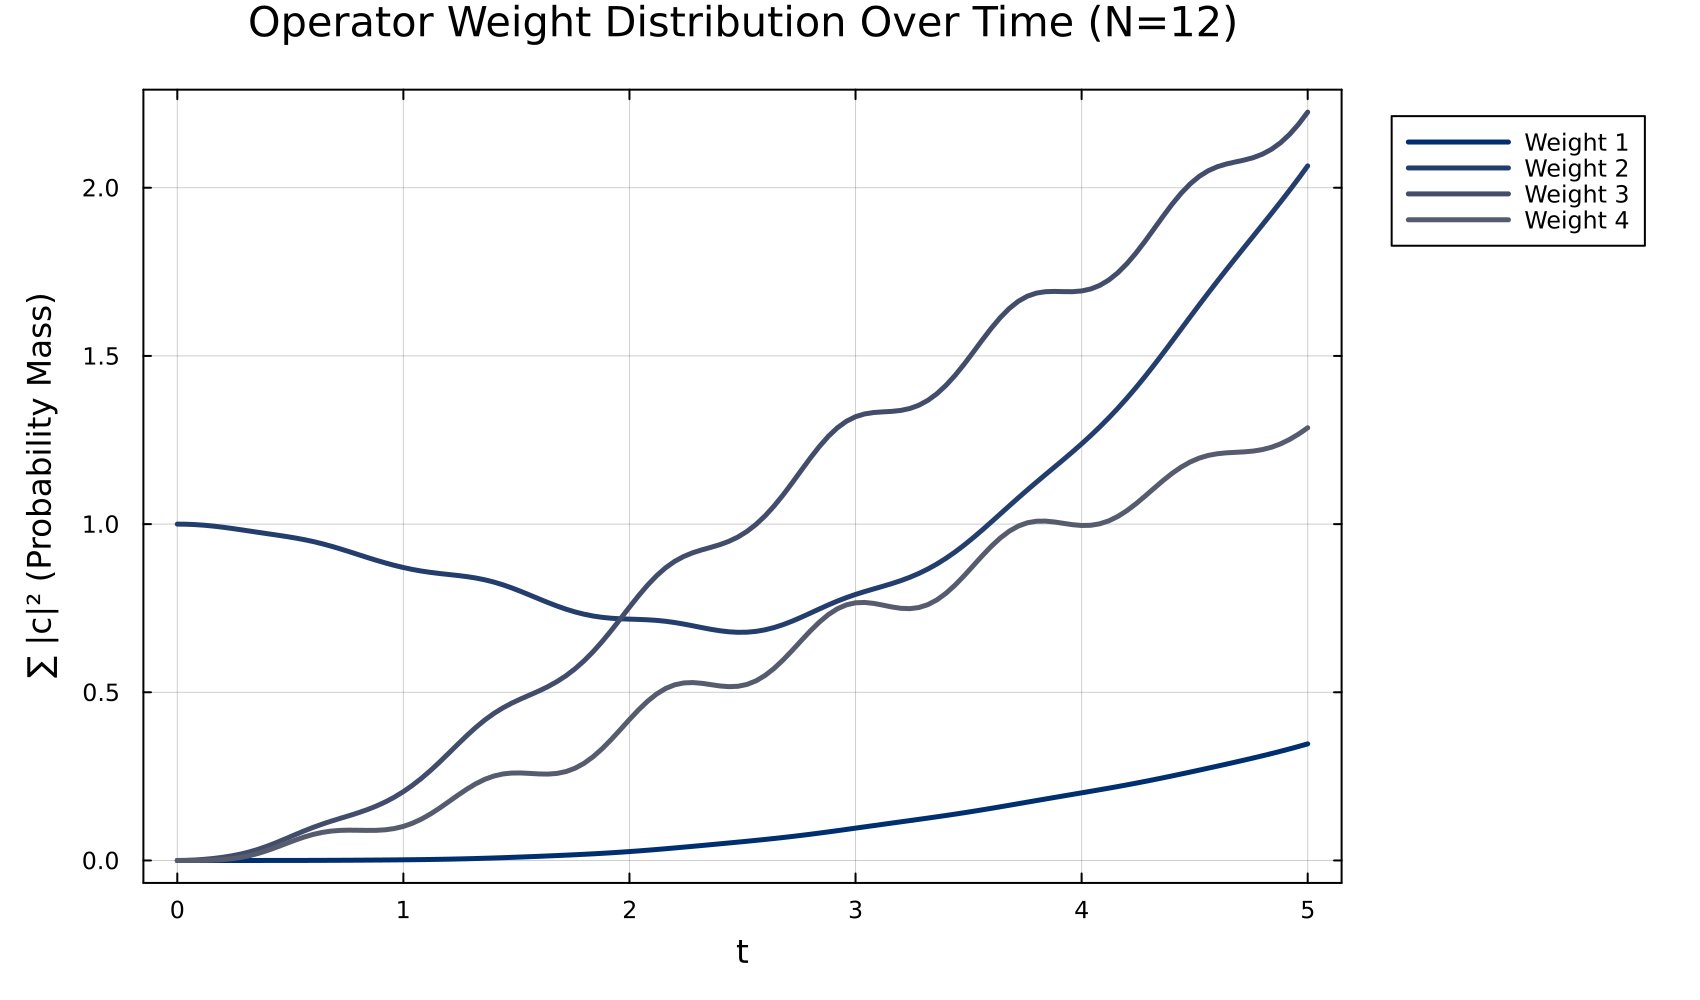

In [66]:
p_dist_mf = plot(xlabel="t", 
              ylabel="∑ |c|² (Probability Mass)",
              title="Operator Weight Distribution Over Time (N=$(N))",
              legend=:outertopright,  # Moves legend outside so it doesn't cover data
              size=(850, 500), 
              framestyle=:box)

# Get a continuous color gradient
my_colors = cgrad(:cividis, N + 1, categorical=true)

for w in 0:N
    # Only plot the line if this weight actually appeared in the simulation
    if maximum(W_mat_mf[:, w+1]) > 1e-10
        plot!(p_dist_mf, times, W_mat_mf[:, w+1], 
              label="Weight $w", 
              linewidth=2.5, 
              color=my_colors[w+1],  margin=5Plots.mm, dpi = 200)
    end
end

display(p_dist_mf)

Now coming up with a mean field approximation to the corrected energy that we do in vDBF and dynamics.

In [ ]:
p2 = plot(times, ev_exact, label="exact",
            color=:black, lw=2.5, ls=:solid,
            xlabel="t", ylabel="⟨ψ| Z_{1, 2}(t) |ψ⟩",
            title="1D Heisenberg XXZ, N=$(N)",
            legend=:topleft, size=(800, 600))

p2


In [ ]:
@time ev_tr, var_tr, nt_tr = trotter_ev_curve(H, O, ψ, times, dt, CoeffTruncation(1e-4))


plot!(p2, times, ev_tr,
          label="Trotter (1e-4)", color=:gray, ls=:dash)
    
p2  

In [ ]:
corr = EnergyCorrection(ψ)
@time ev_tr, var_tr, nt_tr = trotter_ev_curve(H, O, ψ, times, dt, CoeffTruncation(1e-4),  corr)
display(corr)

plot!(p2, times, ev_tr,
          label="Corr Trotter (1e-4)", color=:gray, ls=:dashdot)

p2

In [ ]:


# ── Experimental: CoeffTruncation with mean-field redirect ──────────────────
#
# Like CoeffTruncation(ε), but when a term c·P is dropped (|c| ≤ ε), instead
# of setting it to zero we redirect it to its expectation value on |ψ⟩:
#
#     c · P   →   c · ⟨ψ|P|ψ⟩ · I
#
# For a computational-basis reference, ⟨ψ|P|ψ⟩ is 0 unless P is diagonal
# (no X/Y content), in which case it is ±1 — essentially free to evaluate.
# Preserves ⟨ψ|O|ψ⟩ exactly at the moment of truncation (diff is absorbed
# into the identity coefficient).
using PauliOperators

import PauliOperators: _apply!

struct CoeffTruncationMF{N} <: TruncationStrategy
    thresh::Float64
    reference::Ket{N}
end

function _apply!(O::PauliSum{N,T}, s::CoeffTruncationMF{N}) where {N,T}
    id_key = PauliBasis{N}(Int128(0), Int128(0))
    id_accum = zero(T)
    for (p, c) in collect(O)        # collect to iterate over a snapshot
        p == id_key && continue
        if abs(c) <= s.thresh
            id_accum += c * expectation_value(p, s.reference)
            delete!(O, p)
        end
    end
    if id_accum != zero(T)
        O[id_key] = get(O, id_key, zero(T)) + id_accum
    end
    return O
end
# print("  trotter + mean-field(k=$k_max, ψ)...          ")
@time ev_mf, var_mf, nt_mf = trotter_ev_curve(H, O, ψ, times, dt, CoeffTruncationMF(1e-4, ψ))

# plot!(p2, times, ev_mf,
#           label="MeanFieldTruncation(0, ψ)",
#           color=:gray, lw=2, marker=:square, ms=3)

plot!(p2, times, ev_mf,
          label="MeanFieldTruncation(0, ψ)",
          color=:red, ls = :dashdot)

p2

## EXTRAS

We substitute the fluctuation decomposition $A = \delta A + \langle A \rangle I$ and $B = \delta B + \langle B \rangle I$ into the product $AB$. Expanding the terms gives:

$$
\begin{aligned}
AB &= (\delta A + \langle A \rangle I) \otimes (\delta B + \langle B \rangle I) \\
   &= (\delta A \otimes \delta B) + (\delta A \otimes \langle B \rangle I) + (\langle A \rangle I \otimes \delta B) + (\langle A \rangle I \otimes \langle B \rangle I)
\end{aligned}
$$

Since the expectation values $\langle A \rangle$ and $\langle B \rangle$ are scalar quantities, they commute with the operators. Factoring the scalars out, we get:

$$
\begin{aligned}
AB &= \delta A \otimes \delta B + \langle B \rangle (\delta A \otimes I) + \langle A \rangle (I \otimes \delta B) + \langle A \rangle \langle B \rangle (I \otimes I)
\end{aligned}
$$

$$
AB = \delta A \delta B + \langle B \rangle \delta A + \langle A \rangle \delta B + \langle A \rangle \langle B \rangle I
$$

Now, we resubstitute the definitions of the fluctuations, $\delta A = A - \langle A \rangle I$ and $\delta B = B - \langle B \rangle I$, into the linear terms:

$$AB = \delta A \delta B + \langle B \rangle (A - \langle A \rangle I) + \langle A \rangle (B - \langle B \rangle I) + \langle A \rangle \langle B \rangle I$$

Expanding the products gives:

$$AB = \delta A \delta B + \langle B \rangle A - \langle A \rangle \langle B \rangle I + \langle A \rangle B - \langle A \rangle \langle B \rangle I + \langle A \rangle \langle B \rangle I$$

We can combine and cancel the scalar terms ($-\langle A \rangle \langle B \rangle I - \langle A \rangle \langle B \rangle I + \langle A \rangle \langle B \rangle I = -\langle A \rangle \langle B \rangle I$). This simplifies the exact expansion to:

$$AB = \delta A \delta B + \langle B \rangle A + \langle A \rangle B - \langle A \rangle \langle B \rangle I$$

In mean-field theory, we assume that the fluctuations around the mean field are small. Therefore, the product of two fluctuations, $\delta A \delta B$, is considered a higher-order term and becomes negligible:

$$\delta A \delta B \approx 0$$

By dropping this quadratic fluctuation term, we arrive at the standard mean-field approximation for a 2-body operator. The operator $AB$ is factorized down into a sum of 1-body operators:

$$AB \approx \langle B \rangle A + \langle A \rangle B - \langle A \rangle \langle B \rangle I$$

This is the exact mathematical foundation for why discarding high-weight Pauli strings completely is unphysical, and why replacing them with their localized mean-field values preserves the operator norm.

### 3-Body (ABC) Mean-Field Expansion

Let's do the full 3-body expansion without arbitrarily grouping operators. We assign three individual sites: $A = X_1$, $B = X_2$, and $C = Z_3$.

We start with the 3-body fluctuation decomposition:
$$ABC = (\delta A + \langle A \rangle I) \otimes (\delta B + \langle B \rangle I) \otimes (\delta C + \langle C \rangle I)$$

If we expand this out fully (dropping the explicit $I$ for brevity), we get 8 terms:
$$ABC = \delta A \delta B \delta C + \langle C \rangle \delta A \delta B + \langle B \rangle \delta A \delta C + \langle A \rangle \delta B \delta C + \langle B \rangle \langle C \rangle \delta A + \langle A \rangle \langle C \rangle \delta B + \langle A \rangle \langle B \rangle \delta C + \langle A \rangle \langle B \rangle \langle C \rangle I$$

### Projecting to the $k_{max} = 2$ Subspace

To enforce our weight cutoff of 2, we must drop any fluctuations of weight 3 or higher. Therefore, we assume the pure 3-body fluctuation is negligible:
$$\delta A \delta B \delta C \approx 0$$

If we drop this term, resubstitute our linear fluctuations ($\delta A = A - \langle A \rangle$, etc.), and simplify the algebra, the generic 3-body operator truncated to 2-body terms becomes:

$$ABC \approx \langle C \rangle AB + \langle B \rangle AC + \langle A \rangle BC - \langle A \rangle \langle B \rangle C - \langle A \rangle \langle C \rangle B - \langle B \rangle \langle C \rangle A + \langle A \rangle \langle B \rangle \langle C \rangle I$$

### Applying it to $X_1 X_2 Z_3$

Now, we substitute our specific Pauli operators and their computational basis expectation values. Because purely off-diagonal operators have no expectation value in the $Z$-basis:
* $A = X_1 \implies \langle A \rangle = 0$
* $B = X_2 \implies \langle B \rangle = 0$
* $C = Z_3 \implies \langle C \rangle = \langle Z_3 \rangle$

Plug these into our approximated formula:

$$X_1 X_2 Z_3 \approx \langle Z_3 \rangle (X_1 X_2) + (0)(X_1 Z_3) + (0)(X_2 Z_3) - (0) Z_3 - (0) X_2 - (0) X_1 + (0) I$$

Every term containing $\langle A \rangle$ or $\langle B \rangle$ immediately vanishes, leaving us with:

$$X_1 X_2 Z_3 \approx \langle Z_3 \rangle X_1 X_2$$

**Conclusion:**
By doing the rigorous $ABC$ expansion and dropping the 3-body fluctuation, we arrive at the *exact same* truncated operator as when we arbitrarily grouped $(X_1 X_2)$ into a single term. This proves the mathematical consistency of the mean-field truncation logic across arbitrary subsystem partitions!


---

### How the Julia Implementation Computes This Directly

Expanding polynomials algebraically is computationally expensive. The Julia code uses `_partial_alt_binom` and `_foreach_combination` to bypass the algebraic expansion and calculate the final coefficients directly.

For $P = X_1 Z_2 Z_3$ and $k=2$:
* **Base metrics:** $n_{xy} = 1$ (the $X_1$), and $n_z = 2$ (the two pure $Z$s).
* **Budget:** The allowed number of $Z$ operators we can keep is $k - n_{xy} = 2 - 1 = 1$.
* **Generating terms:** The code iterates through the number of $Z$ operators to keep ($t = 0$ to $1$).

**Case $t=0$ (Keep zero $Z$ operators):**
* **Combinations:** There is only one way to choose zero $Z$s. The remaining base operator is just $X_1$.
* **Coefficient factor:** The code calls `_partial_alt_binom(n_z - t, budget - t)`, which evaluates to `_partial_alt_binom(2, 1)`.
* **Math:** $\sum_{m=0}^1 \binom{2}{m}(-1)^m = \binom{2}{0} - \binom{2}{1} = 1 - 2 = -1$.
* **Result:** It adds $-1 \times X_1$ to the `PauliSum`.

**Case $t=1$ (Keep one $Z$ operator):**
* **Combinations:** $\{Z_2\}$ and $\{Z_3\}$. If we keep $Z_2$, the "dropped" $Z_3$ is evaluated as its scalar expectation value ($\varepsilon_3 = 1$).
* **Coefficient factor:** `_partial_alt_binom(2-1, 1-1)` $\rightarrow$ `_partial_alt_binom(1, 0)`.
* **Math:** $\sum_{m=0}^0 \binom{1}{m}(-1)^m = 1$.
* **Result:** It adds $+1 \times X_1 Z_2$ and $+1 \times X_1 Z_3$ to the `PauliSum`.

The code perfectly outputs $X_1 Z_2 + X_1 Z_3 - X_1$ without ever creating intermediate memory allocations for the $\delta$ substitutions.

> **Note on the Zero-Body Limit ($k=0$):**
> When this factorization is evaluated at the strict $k=0$ limit, any operator with $X$ or $Y$ components ($n_{xy} > 0$) immediately exceeds the available budget and is discarded (which is why $X_1 Z_2 Z_3 \rightarrow 0$). However, for pure-$Z$ strings, all $Z$ operators are forced to be evaluated as their scalar expectation values ($t=0$). The entire operator reduces to a single scalar value. This elegantly produces a zero-body mean-field approximation that acts natively as the energy correction for the algorithm, rather than treating the energy correction as a distinct, manually added corrective term later in the calculation.

### Mathematical Formulation of Mean-Field Truncation

Let $P_j$ be a high-weight Pauli string such that $W(P_j) > k_{max}$. For a computational basis reference state $|\psi\rangle$, the local expectation values are $\langle X_i \rangle = \langle Y_i \rangle = 0$ and $\langle Z_i \rangle \in \{+1, -1\}$. 

If the number of $X$ and $Y$ operators ($k_{xy}$) in $P_j$ exceeds $k_{max}$, the mean-field projection is strictly zero. If $k_{xy} \le k_{max}$, we apply the fluctuation decomposition to the remaining $n_z$ pure $Z$ operators. 

We rewrite each $Z_i$ as:
$$Z_i = \delta Z_i + \langle Z_i \rangle I$$
where $\delta Z_i = Z_i - \langle Z_i \rangle I$.

Substituting this into the Pauli string and expanding the product, we truncate the operator by restricting the number of fluctuation terms ($\delta Z$) we retain. Let the remaining weight budget be $k_{budget} = k_{max} - k_{xy}$. The truncated operator is formed by summing over all subsets $T$ of the $Z$-sites with size $|T| = t \le k_{budget}$:

$$P_{j}^{MF} = \sum_{t=0}^{\min(n_z, k_{budget})} f(n_z, t) \sum_{|T|=t} \left( \prod_{i \in T} Z_i \prod_{m \notin T} \langle Z_m \rangle \right) \otimes P_{X,Y}$$

Here, $f(n_z, t)$ is the combinatoric factor representing the accumulated background contributions from the traced-out $Z$ operators. It is evaluated as an alternating binomial sum:

$$f(n_z, t) = \sum_{m=0}^{k_{budget}-t} \binom{n_z - t}{m} (-1)^m$$

By absorbing the scalar expectation values $\langle Z_m \rangle$ into the operator coefficients, we project the high-weight Pauli string exactly down into the $k_{max}$ subspace while preserving its mean-field effect on the system.

# Eigenvector as a state

Now in this what if we use an eigenvector instead of a normal state. The mean field should perform better when the eigenvector is a single slater determinant. I guess with the multi state eigenstate the sstate can be maximally mixed state and single pauli expectation value would be zero. 